In [2]:
#importar paquetes
#GUARDAR
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [3]:
# =========================
# BLOQUE 0: Carga excel
# =========================
file_path = "Amina DEA - Históricos 2024 2025.xlsx"

df = pd.read_excel(file_path, sheet_name="Sheet1")

In [4]:
# =========================
# BLOQUE 1: Separar 2024 y 2025
# =========================
df_2024 = df.iloc[:, 0:4].copy()
df_2025 = df.iloc[:, 4:8].copy()

df_2024.columns = ["Fecha", "Flujo_T306", "Flujo_Merichem", "Flujo_OSBL"]
df_2025.columns = ["Fecha", "Flujo_T306", "Flujo_Merichem", "Flujo_OSBL"]

# Convertir fechas
df_2024["Fecha"] = pd.to_datetime(df_2024["Fecha"], format="%d-%b-%y %H:%M:%S", errors="coerce")
df_2025["Fecha"] = pd.to_datetime(df_2025["Fecha"], format="%d-%b-%y %H:%M:%S", errors="coerce")

In [5]:
# =========================
# BLOQUE 2: Merge vertical
# =========================
df_merged = pd.concat([df_2024, df_2025], axis=0)

df_merged = (
    df_merged
    .dropna(subset=["Fecha"])
    .sort_values("Fecha")
    .drop_duplicates(subset="Fecha")
    .set_index("Fecha")
)

In [6]:
df_merged.head()

,Flujo_T306,Flujo_Merichem,Flujo_OSBL
Fecha,,,
2024-01-01 00:00:00,1213.722818,38.130482,1208.162199
2024-01-01 00:01:00,1213.12587,38.113681,1208.140514
2024-01-01 00:02:00,1212.528923,38.096879,1208.118828
2024-01-01 00:03:00,1211.931975,38.080078,1208.097142
2024-01-01 00:04:00,1211.335027,38.063276,1208.075457


In [7]:
# =========================
# BLOQUE 3: Suma con indentación de NaN
# =========================

# Convertir a numérico textos como "No Good Data For Calculation" = NaN
#columna auxiliar para Flujo_T306
df_merged["Flujo_T306_num"] = pd.to_numeric(df_merged["Flujo_T306"], errors="coerce")
#columna auxiliar para Flujo_Merichem
df_merged["Flujo_Merichem_num"] = pd.to_numeric(df_merged["Flujo_Merichem"], errors="coerce")
#columna auxiliar para Flujo_OSBL
df_merged["Flujo_OSBL_num"] = pd.to_numeric(df_merged["Flujo_OSBL"], errors="coerce")

# Identificar entradas problemáticas:
# 1) No numéricas (NaN)
# 2) Negativos
mask_problem = (
    df_merged["Flujo_T306_num"].isna() |
    df_merged["Flujo_Merichem_num"].isna() |
    df_merged["Flujo_OSBL_num"].isna() |
    (df_merged["Flujo_T306_num"] < 0) |
    (df_merged["Flujo_Merichem_num"] < 0) |
    (df_merged["Flujo_OSBL_num"] < 0)
)

# Crear columna suma condicional:
#df_merged["Flujo_Total_LCGO"] = (
 #   df_merged["Flujo_U108_num"] + df_merged["Flujo_U109_num"] + df_merged["Flujo_Tanques_num"]
#)

# Indentar resultado de suma por NaN (entradas problemáticas)
df_merged.loc[mask_problem, "Flujo_T306_num"] = np.nan
df_merged.loc[mask_problem, "Flujo_Merichem_num"] = np.nan
df_merged.loc[mask_problem, "Flujo_OSBL_num"] = np.nan

In [8]:
# =========================
# BLOQUE 4: Preparar datos para graficar
# =========================
import numpy as np
import matplotlib.pyplot as plt

# Convertir a numérico y forzar negativos a NaN
for col in ["Flujo_T306", "Flujo_Merichem", "Flujo_OSBL"]:
    df_merged[col] = pd.to_numeric(df_merged[col], errors="coerce")
    df_merged.loc[df_merged[col] < 0, col] = np.nan

In [9]:
# =========================
# BLOQUE 5.0: Mediana por columna (vector independiente)
# =========================

# Asegurar numérico y negativos como NaN
df_merged["Flujo_T306"] = pd.to_numeric(df_merged["Flujo_T306"], errors="coerce")
df_merged["Flujo_Merichem"] = pd.to_numeric(df_merged["Flujo_Merichem"], errors="coerce")
df_merged["Flujo_OSBL"] = pd.to_numeric(df_merged["Flujo_OSBL"], errors="coerce")

df_merged.loc[df_merged["Flujo_T306"] < 0, "Flujo_T306"] = np.nan
df_merged.loc[df_merged["Flujo_Merichem"] < 0, "Flujo_Merichem"] = np.nan
df_merged.loc[df_merged["Flujo_OSBL"] < 0, "Flujo_OSBL"] = np.nan

# Medianas individuales
mediana_T306 = df_merged["Flujo_T306"].median(skipna=True)
mediana_Merichem = df_merged["Flujo_Merichem"].median(skipna=True)
mediana_OSBL = df_merged["Flujo_OSBL"].median(skipna=True)

print("Mediana Flujo_T306:", mediana_T306)
print("Mediana Flujo_Merichem:", mediana_Merichem)
print("Mediana Flujo_OSBL:", mediana_OSBL)

Mediana Flujo_T306: 1478.9736358631594
Mediana Flujo_Merichem: 21.44679033188593
Mediana Flujo_OSBL: 1503.0409782446172


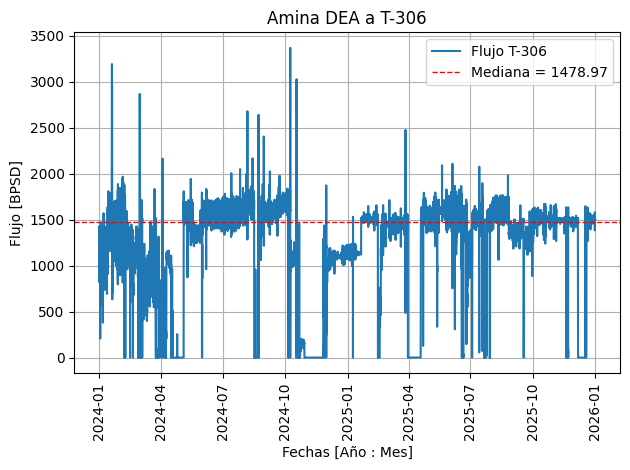

In [33]:
# =========================
# BLOQUE 5.1: Gráfico discontinuo Flujo T306
# =========================
#plt.figure(figsize=(14,6))

plt.plot(df_merged.index, df_merged["Flujo_T306"], label="Flujo T-306")

plt.axhline(mediana_T306, linestyle="--", linewidth=1, color='r',
            label=f"Mediana = {mediana_T306:.2f}")

plt.xlabel("Fechas [Año : Mes]")
plt.ylabel("Flujo [BPSD]")
plt.xticks(rotation=90)
plt.title("Amina DEA a T-306")
plt.legend()
plt.tight_layout()
plt.grid(True)
plt.show()

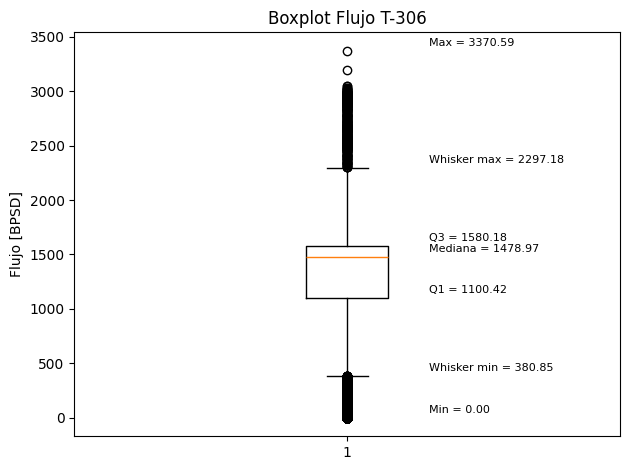

In [34]:
data_T306 = df_merged["Flujo_T306"].dropna()

box = plt.boxplot(data_T306, showfliers=True)

ymin, ymax = plt.ylim()
offset = (ymax - ymin) * 0.02

q1 = data_T306.quantile(0.25)
q3 = data_T306.quantile(0.75)

whiskers = box['whiskers']
low_whisker = whiskers[0].get_ydata()[1] # extremo inferior
high_whisker = whiskers[1].get_ydata()[1] # extremo superior

min_val = data_T306.min()
max_val = data_T306.max()

plt.text(1.15, mediana_T306 + 0.02*(ymax - ymin),
         f"Mediana = {mediana_T306:.2f}",
         verticalalignment='center', fontsize=8)

plt.text(1.15, q1 + offset, f"Q1 = {q1:.2f}", verticalalignment='center', fontsize=8)
plt.text(1.15, q3 + offset, f"Q3 = {q3:.2f}", verticalalignment='center', fontsize=8)

plt.text(1.15, low_whisker + offset, f"Whisker min = {low_whisker:.2f}", verticalalignment='center', fontsize=8)
plt.text(1.15, high_whisker + offset, f"Whisker max = {high_whisker:.2f}", verticalalignment='center', fontsize=8)

plt.text(1.15, min_val + offset, f"Min = {min_val:.2f}", verticalalignment='center', fontsize=8)
plt.text(1.15, max_val + offset, f"Max = {max_val:.2f}", verticalalignment='center', fontsize=8)

plt.ylabel("Flujo [BPSD]")
plt.title("Boxplot Flujo T-306")
plt.tight_layout()
plt.show()

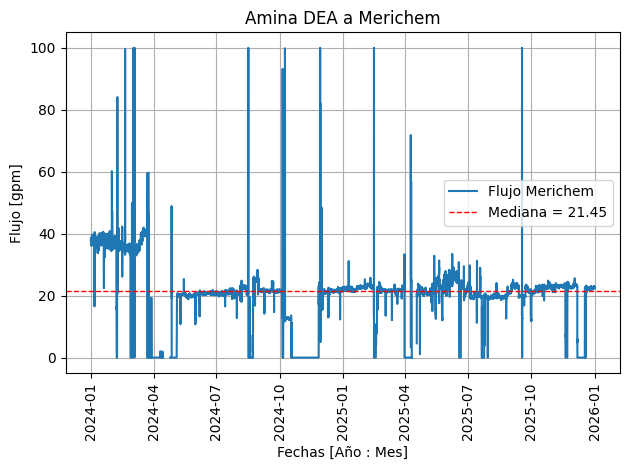

In [35]:
# =========================
# BLOQUE 5.1: Gráfico discontinuo Flujo Merichem
# =========================
#plt.figure(figsize=(14,6))

plt.plot(df_merged.index, df_merged["Flujo_Merichem"], label="Flujo Merichem")

plt.axhline(mediana_Merichem, linestyle="--", linewidth=1, color='r',
            label=f"Mediana = {mediana_Merichem:.2f}")

plt.xlabel("Fechas [Año : Mes]")
plt.ylabel("Flujo [gpm]")
plt.xticks(rotation=90)
plt.title("Amina DEA a Merichem")
plt.legend()
plt.tight_layout()
plt.grid(True)
plt.show()

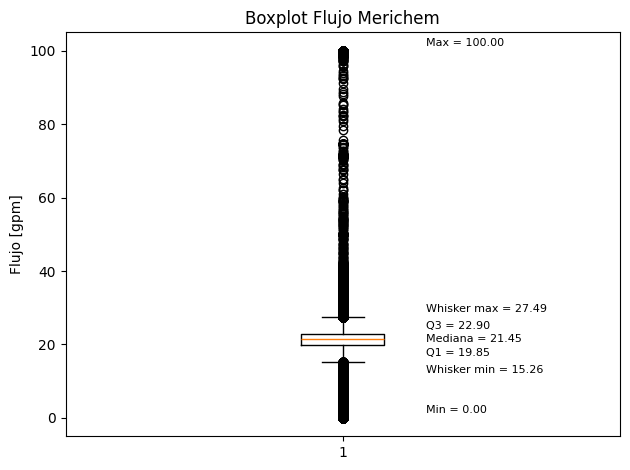

In [36]:
data_Merichem = df_merged["Flujo_Merichem"].dropna()

box = plt.boxplot(data_Merichem, showfliers=True)

ymin, ymax = plt.ylim()
offset = (ymax - ymin) * 0.02

q1 = data_Merichem.quantile(0.25)
q3 = data_Merichem.quantile(0.75)

whiskers = box['whiskers']
low_whisker = whiskers[0].get_ydata()[1] # extremo inferior
high_whisker = whiskers[1].get_ydata()[1] # extremo superior

min_val = data_Merichem.min()
max_val = data_Merichem.max()

plt.text(1.15, mediana_Merichem,
         f"Mediana = {mediana_Merichem:.2f}",
         verticalalignment='center', fontsize=8)

plt.text(1.15, q1 - offset, f"Q1 = {q1:.2f}", verticalalignment='center', fontsize=8)
plt.text(1.15, q3 + offset, f"Q3 = {q3:.2f}", verticalalignment='center', fontsize=8)

plt.text(1.15, low_whisker - offset, f"Whisker min = {low_whisker:.2f}", verticalalignment='center', fontsize=8)
plt.text(1.15, high_whisker + offset, f"Whisker max = {high_whisker:.2f}", verticalalignment='center', fontsize=8)

plt.text(1.15, min_val + offset, f"Min = {min_val:.2f}", verticalalignment='center', fontsize=8)
plt.text(1.15, max_val + offset, f"Max = {max_val:.2f}", verticalalignment='center', fontsize=8)

plt.ylabel("Flujo [gpm]")
plt.title("Boxplot Flujo Merichem")
plt.tight_layout()
plt.show()

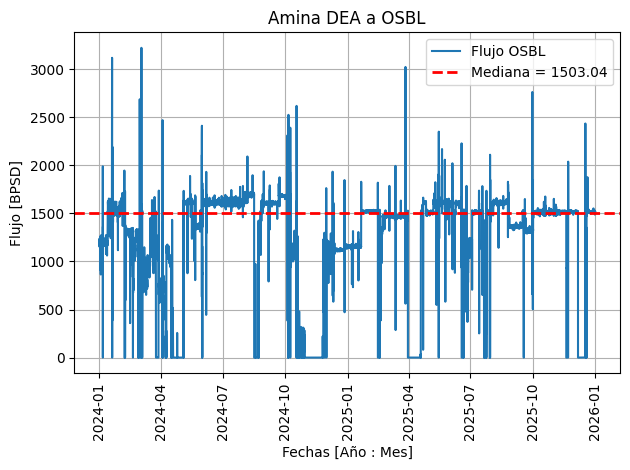

In [37]:
# =========================
# BLOQUE 5.2: Gráfico discontinuo Flujo OSBL
# =========================
#plt.figure(figsize=(14,6))

plt.plot(df_merged.index, df_merged["Flujo_OSBL"], label="Flujo OSBL")

plt.axhline(mediana_OSBL, linestyle="--", linewidth=2, color='r',
            label=f"Mediana = {mediana_OSBL:.2f}")

plt.xlabel("Fechas [Año : Mes]")
plt.ylabel("Flujo [BPSD]")
plt.xticks(rotation=90)
plt.title("Amina DEA a OSBL")
plt.legend()
plt.tight_layout()
plt.grid(True)
plt.show()

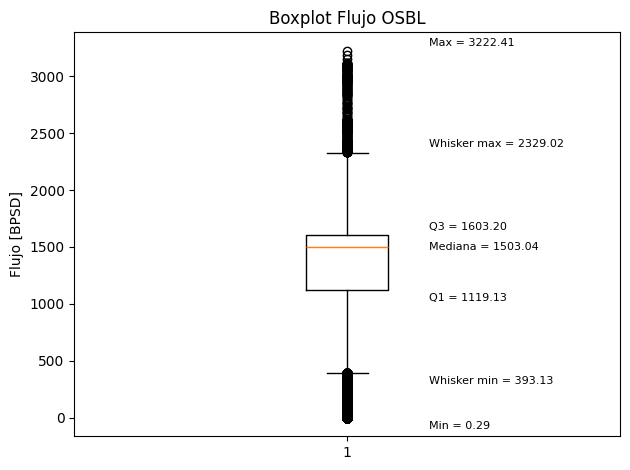

In [38]:
data_OSBL = df_merged["Flujo_OSBL"].dropna()

box = plt.boxplot(data_OSBL, showfliers=True)

ymin, ymax = plt.ylim()
offset = (ymax - ymin) * 0.02

q1 = data_OSBL.quantile(0.25)
q3 = data_OSBL.quantile(0.75)

whiskers = box['whiskers']
low_whisker = whiskers[0].get_ydata()[1] # extremo inferior
high_whisker = whiskers[1].get_ydata()[1] # extremo superior

min_val = data_OSBL.min()
max_val = data_OSBL.max()

plt.text(1.15, mediana_OSBL,
         f"Mediana = {mediana_OSBL:.2f}",
         verticalalignment='center', fontsize=8)

plt.text(1.15, q1 - offset, f"Q1 = {q1:.2f}", verticalalignment='center', fontsize=8)
plt.text(1.15, q3 + offset, f"Q3 = {q3:.2f}", verticalalignment='center', fontsize=8)

plt.text(1.15, low_whisker - offset, f"Whisker min = {low_whisker:.2f}", verticalalignment='center', fontsize=8)
plt.text(1.15, high_whisker + offset, f"Whisker max = {high_whisker:.2f}", verticalalignment='center', fontsize=8)

plt.text(1.15, min_val - offset, f"Min = {min_val:.2f}", verticalalignment='center', fontsize=8)
plt.text(1.15, max_val + offset, f"Max = {max_val:.2f}", verticalalignment='center', fontsize=8)

plt.ylabel("Flujo [BPSD]")
plt.title("Boxplot Flujo OSBL")
plt.tight_layout()
plt.show()

In [16]:
columnas = ["Flujo_T306", "Flujo_Merichem", "Flujo_OSBL"]

# Asegurar formato numérico y negativos como NaN
for col in columnas:
    df_merged[col] = pd.to_numeric(df_merged[col], errors="coerce")
    df_merged.loc[df_merged[col] < 0, col] = np.nan

# Crear columna año desde el índice temporal
df_merged["Año"] = df_merged.index.year

# Calcular medianas por año
medianas_por_año = df_merged.groupby("Año")[columnas].median()

print("Medianas por año:")
print(medianas_por_año)

Medianas por año:
       Flujo_T306  Flujo_Merichem   Flujo_OSBL
Año                                           
2024  1301.728919       20.933147  1309.966623
2025  1493.184439       21.807271  1509.867539
